In [1]:
import numpy as np
import matplotlib.pyplot as plt

from iqwav.correlation import (
    autocorrelation,
    normalized_autocorrelation,
)

In [2]:
## normalized autocorrelation

x = np.tile([1.0, 0.0, 0.0], 20)

r = normalized_autocorrelation(x, max_lag=15)

print(np.round(r, 3))

[1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1.]


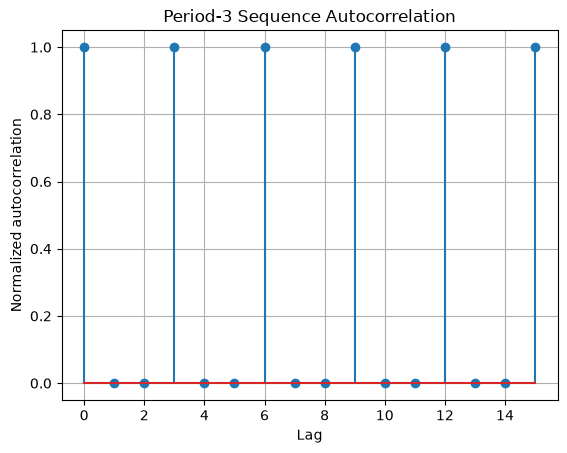

In [3]:
lags = np.arange(len(r))

plt.stem(lags, r)
plt.xlabel("Lag")
plt.ylabel("Normalized autocorrelation")
plt.title("Period-3 Sequence Autocorrelation")
plt.grid()
plt.show()

In [4]:
## complex tone

fs = 1000
f = 125
n = np.arange(1000)

iq = np.exp(1j * 2*np.pi*f*n/fs)

r_iq = normalized_autocorrelation(iq, max_lag=4)

print("Correlation:")
print(r_iq)

print("\nAngle of R[1]:", np.angle(r_iq[1]))
print("Expected angle:", 2*np.pi*f/fs)

Correlation:
[ 1.00000000e+00+0.00000000e+00j  7.07106781e-01+7.07106781e-01j
 -9.55314652e-16+1.00000000e+00j -7.07106781e-01+7.07106781e-01j
 -1.00000000e+00+1.31525465e-15j]

Angle of R[1]: 0.7853981633974483
Expected angle: 0.7853981633974483


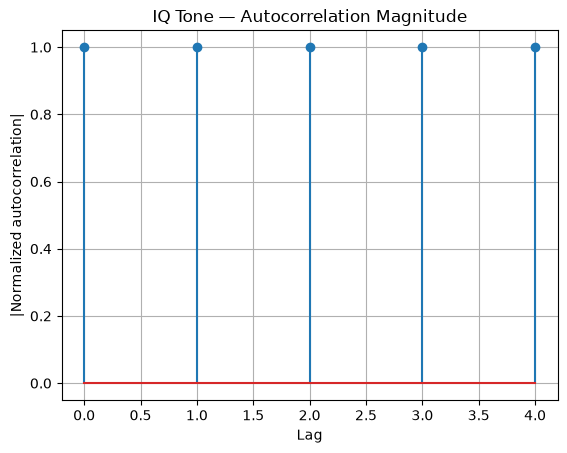

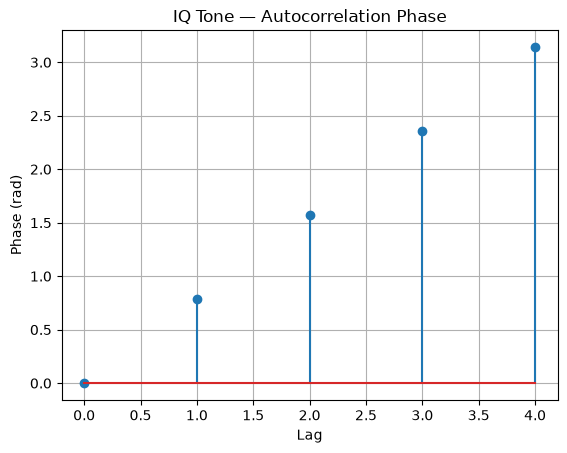

In [5]:
lags = np.arange(len(r_iq))

plt.stem(lags, np.abs(r_iq))
plt.xlabel("Lag")
plt.ylabel("|Normalized autocorrelation|")
plt.title("IQ Tone — Autocorrelation Magnitude")
plt.grid()
plt.show()

plt.stem(lags, np.angle(r_iq))
plt.xlabel("Lag")
plt.ylabel("Phase (rad)")
plt.title("IQ Tone — Autocorrelation Phase")
plt.grid()
plt.show()

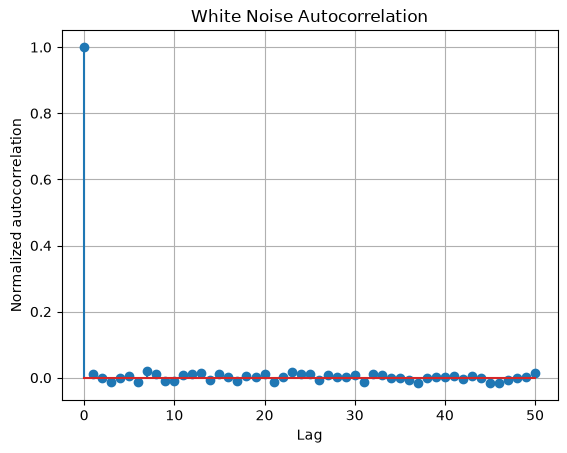

Largest non-zero-lag magnitude: 0.02005944477753974


In [6]:
## white noise

rng = np.random.default_rng(42)

noise = rng.normal(size=10000)

r_noise = normalized_autocorrelation(
    noise,
    max_lag=50
)

plt.stem(
    np.arange(len(r_noise)),
    r_noise
)

plt.xlabel("Lag")
plt.ylabel("Normalized autocorrelation")
plt.title("White Noise Autocorrelation")
plt.grid()
plt.show()

print(
    "Largest non-zero-lag magnitude:",
    np.max(np.abs(r_noise[1:]))
)

In [7]:
from iqwav.estimation import detect_occupied_bands

In [8]:
rng = np.random.default_rng(42)

fs = 1_000_000
N = 65536

freqs = np.fft.fftfreq(N, d=1/fs)

# Random complex spectrum
X = (
    rng.normal(size=N)
    + 1j * rng.normal(size=N)
)

# Keep only a 60 kHz-wide region around +100 kHz
mask = (freqs >= 70_000) & (freqs <= 130_000)

X_band = X * mask
signal_band = np.fft.ifft(X_band)

# Normalize its power
signal_band /= np.sqrt(np.mean(np.abs(signal_band)**2))

# Add weaker complex white noise
noise = (
    rng.normal(size=N)
    + 1j * rng.normal(size=N)
) / np.sqrt(2)

noise *= 0.1

x = signal_band + noise

In [9]:
bands, noise_floor_db = detect_occupied_bands(
    x,
    fs,
    nperseg=4096,
    threshold_db=6,
    min_bins=3
)

print("Noise floor:", noise_floor_db, "dB")
print()

for band in bands:
    print(band)

Noise floor: -80.00732595066181 dB

OccupiedBand(lower_hz=69702.1484375, upper_hz=130249.0234375, center_hz=99975.5859375, bandwidth_hz=60546.875, peak_hz=90820.3125, peak_db=-45.53352751688557, peak_above_noise_db=34.47379843377624)


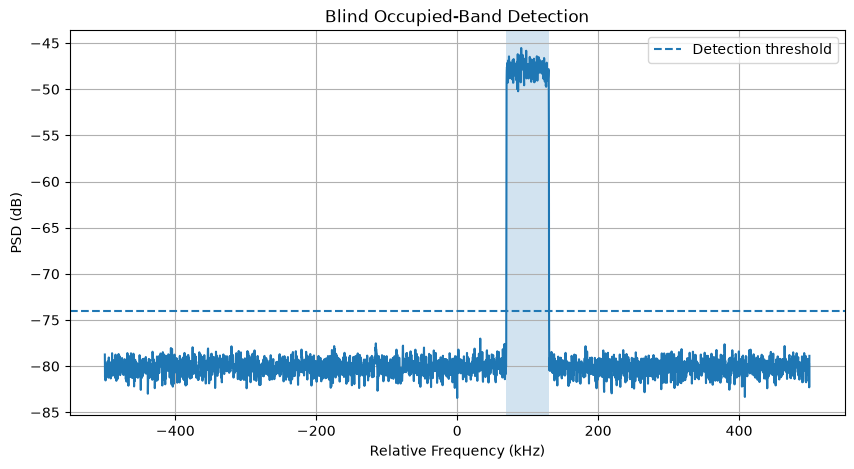

In [10]:
from iqwav.dsp import welch_psd

f_psd, p_psd = welch_psd(
    x,
    fs,
    nperseg=4096
)

p_db = 10 * np.log10(p_psd)

plt.figure(figsize=(10, 5))
plt.plot(f_psd / 1000, p_db)

plt.axhline(
    noise_floor_db + 6,
    linestyle="--",
    label="Detection threshold"
)

for band in bands:
    plt.axvspan(
        band.lower_hz / 1000,
        band.upper_hz / 1000,
        alpha=0.2
    )

plt.xlabel("Relative Frequency (kHz)")
plt.ylabel("PSD (dB)")
plt.title("Blind Occupied-Band Detection")
plt.legend()
plt.grid()
plt.show()

In [11]:
rng = np.random.default_rng(123)

noise_only = (
    rng.normal(size=65536)
    + 1j * rng.normal(size=65536)
) / np.sqrt(2)

noise_bands, noise_floor = detect_occupied_bands(
    noise_only,
    fs,
    nperseg=4096,
    threshold_db=6,
    min_bins=3
)

print("Detected bands:", noise_bands)
print("Noise floor:", noise_floor)

Detected bands: []
Noise floor: -60.067306831310276


In [12]:
## Blind In-Band SNR Estimation

In [13]:
from iqwav.estimation import (
    detect_occupied_bands,
    estimate_band_snr,
)

rng = np.random.default_rng(123)

fs = 1_000_000
N = 65536

true_lower = 70_000
true_upper = 130_000
true_bandwidth = true_upper - true_lower

freqs = np.fft.fftfreq(N, d=1/fs)

# Create random complex energy only inside the desired band
X = (
    rng.normal(size=N)
    + 1j * rng.normal(size=N)
)

mask = (
    (freqs >= true_lower)
    & (freqs <= true_upper)
)

signal_band = np.fft.ifft(X * mask)

# Normalize signal power to approximately 1
signal_band /= np.sqrt(
    np.mean(np.abs(signal_band)**2)
)

# Desired IN-BAND SNR
target_snr_db = 10
target_snr_linear = 10**(target_snr_db / 10)

# Broadband white noise:
# only bandwidth/fs of its total power falls inside our signal band
noise_total_power = (
    fs
    / (true_bandwidth * target_snr_linear)
)

noise = (
    rng.normal(size=N)
    + 1j * rng.normal(size=N)
) / np.sqrt(2)

noise *= np.sqrt(noise_total_power)

x_snr = signal_band + noise

print("Target in-band SNR:", target_snr_db, "dB")

Target in-band SNR: 10 dB


In [14]:
# detecting the band

bands_snr, floor_snr = detect_occupied_bands(
    x_snr,
    fs,
    nperseg=4096,
    threshold_db=6,
    min_bins=3
)

for band in bands_snr:
    print(band)

OccupiedBand(lower_hz=69946.2890625, upper_hz=130004.8828125, center_hz=99975.5859375, bandwidth_hz=60058.59375, peak_hz=96191.40625, peak_db=-45.50445674076304, peak_above_noise_db=12.256278174856483)


In [15]:
# estimate snr

band = max(
    bands_snr,
    key=lambda b: b.bandwidth_hz
)

snr_result = estimate_band_snr(
    x_snr,
    fs,
    band,
    nperseg=4096
)

print("Target SNR:    ", target_snr_db, "dB")
print("Estimated SNR: ", snr_result.snr_db, "dB")

print()
print("Signal power:       ", snr_result.signal_power)
print("Noise power:        ", snr_result.noise_power)
print("Total in-band power:", snr_result.total_inband_power)
print("Noise PSD:          ", snr_result.noise_psd)
print("Noise PSD dB:       ", snr_result.noise_psd_db)

Target SNR:     10 dB
Estimated SNR:  10.049524264956144 dB

Signal power:        1.0028408734575343
Noise power:         0.09914700506105233
Total in-band power: 1.1019878785185866
Noise PSD:           1.650837937927115e-06
Noise PSD dB:        -57.822955591530665


### Blind Symbol / Baud Rate Estimation

In [16]:
import numpy as np

from iqwav.modulation import bpsk_waveform
from iqwav.estimation import estimate_symbol_rate

rng = np.random.default_rng(42)

fs = 80_000
true_sps = 8

bits = rng.integers(0, 2, size=2000)

wave = bpsk_waveform(
    bits,
    samples_per_symbol=true_sps
)

result = estimate_symbol_rate(
    wave,
    fs,
    min_sps=2,
    max_sps=32
)

print("True SPS:", true_sps)
print("Estimated SPS:", result.samples_per_symbol)

print()
print("True symbol rate:", fs / true_sps, "baud")
print("Estimated symbol rate:", result.symbol_rate_hz, "baud")
print("Score:", result.score)

True SPS: 8
Estimated SPS: 8

True symbol rate: 10000.0 baud
Estimated symbol rate: 10000.0 baud
Score: 0.45980307760708067


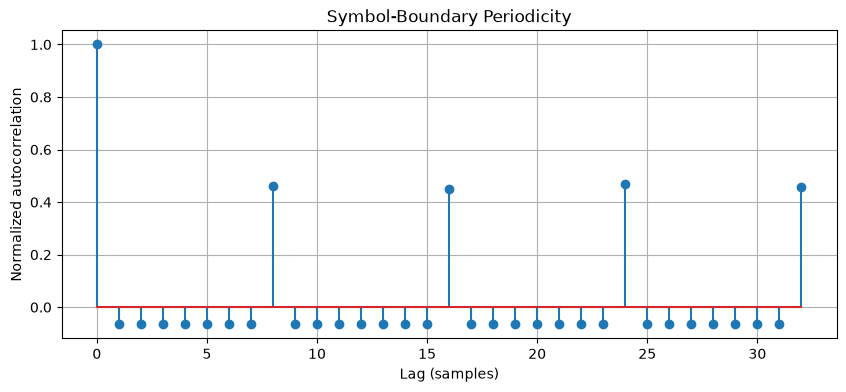

In [17]:
import matplotlib.pyplot as plt

from iqwav.correlation import normalized_autocorrelation

transition_energy = np.abs(
    wave[1:] - wave[:-1]
)**2

transition_centered = (
    transition_energy
    - np.mean(transition_energy)
)

r_transition = normalized_autocorrelation(
    transition_centered,
    max_lag=32
)

plt.figure(figsize=(10, 4))
plt.stem(
    np.arange(len(r_transition)),
    r_transition
)

plt.xlabel("Lag (samples)")
plt.ylabel("Normalized autocorrelation")
plt.title("Symbol-Boundary Periodicity")
plt.grid()
plt.show()

In [18]:
from iqwav.modulation import qpsk_waveform
from iqwav.dsp import add_awgn

bits_qpsk = rng.integers(
    0,
    2,
    size=4000
)

qpsk = qpsk_waveform(
    bits_qpsk,
    samples_per_symbol=8
)

qpsk_noisy = add_awgn(
    qpsk,
    snr_db=10,
    rng=rng
)

result_qpsk = estimate_symbol_rate(
    qpsk_noisy,
    fs,
    min_sps=2,
    max_sps=32
)

print("Estimated SPS:", result_qpsk.samples_per_symbol)
print("Estimated baud:", result_qpsk.symbol_rate_hz)
print("Score:", result_qpsk.score)

Estimated SPS: 8
Estimated baud: 10000.0
Score: 0.5384965107528568
